# GNSS Telemetry Viewer

Plot `qerr_ns` versus F9T/agent telemetry time for each DAQ node. Each node is drawn in a separate color and labeled in the legend.

Edit the `telemetry_file` cell if you want to point this notebook at a different telemetry JSONL file.

In [1]:
from __future__ import annotations

import gzip
import json
import re
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

# Formatting for plots
label_font = {'fontname':'sans-serif', 'size':'18', 'color':'black', 'weight':'bold',
          'verticalalignment':'bottom'} 
title_font = {'fontname':'sans-serif', 'size':'20', 'color':'black', 'weight':'bold'}
legend_font = {'family':'sans-serif', 'size':'12', 'style':'normal', 'weight':'bold'}
PT_TZ = ZoneInfo('America/Los_Angeles')

## Select Telemetry File

Set `telemetry_file` to the server telemetry JSONL file you want to plot. Server telemetry files usually contain records from multiple nodes and include an `alias` field.

In [ ]:
# Paste a different telemetry filename here when needed. Relative paths are evaluated from the repo root.
repo_root = Path.cwd()
if not (repo_root / 'gnss_scripts').exists() and (repo_root.parent / 'gnss_scripts').exists():
    repo_root = repo_root.parent

telemetry_file = Path('Sandbox/telemetry_20260703_001014Z.jsonl')
telemetry_path = telemetry_file if telemetry_file.is_absolute() else repo_root / telemetry_file
if not telemetry_path.exists():
    raise FileNotFoundError(f'Telemetry file not found: {telemetry_path}')

telemetry_files = [telemetry_path]
print('Using telemetry file:', telemetry_path.relative_to(repo_root) if telemetry_path.is_relative_to(repo_root) else telemetry_path)

Using telemetry file: Sandbox/telemetry_20260702_224344Z.jsonl


In [44]:
def open_text(path: Path):
    """Open plain or gzip-compressed telemetry as text."""
    if path.suffix == '.gz':
        return gzip.open(path, 'rt', encoding='utf-8')
    return path.open('r', encoding='utf-8')


def node_from_filename(path: Path) -> str:
    """Infer a node label from agent-local telemetry filenames."""
    name = path.name.removesuffix('.gz').removesuffix('.jsonl')
    name = re.sub(r'_\d{8}_\d{6}Z$', '', name)
    if name.startswith('telemetry_'):
        return 'server'
    if name.startswith('UNKNOWN'):
        return 'UNKNOWN'
    return name


def load_telemetry(files: list[Path]) -> pd.DataFrame:
    rows = []
    bad_lines = 0
    for path in files:
        fallback_node = node_from_filename(path)
        with open_text(path) as handle:
            for line_no, line in enumerate(handle, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    bad_lines += 1
                    continue

                qerr = rec.get('qerr_ns')
                unix_ms = rec.get('unix_ms') or rec.get('gnss_unix_ms') or rec.get('receiver_unix_ms')
                if qerr is None or unix_ms is None:
                    continue

                node = rec.get('alias') or rec.get('daq_name') or rec.get('node') or fallback_node
                if node in {'', None, 'server'}:
                    node = rec.get('device_id') or fallback_node

                rows.append({
                    'node': str(node),
                    'device_id': rec.get('device_id', ''),
                    'unix_ms': int(unix_ms),
                    'time_utc': pd.to_datetime(int(unix_ms), unit='ms', utc=True),
                    'qerr_ns': float(qerr),
                    'source_file': str(path.relative_to(repo_root)),
                })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['node', 'time_utc']).reset_index(drop=True)
    print(f'Loaded {len(df)} qerr records from {len(files)} files; skipped {bad_lines} malformed lines')
    return df


df = load_telemetry(telemetry_files)
if not df.empty:
    df['time_pt'] = df['time_utc'].dt.tz_convert(PT_TZ)
df.head()

Loaded 17751 qerr records from 1 files; skipped 0 malformed lines


,node,device_id,unix_ms,time_utc,qerr_ns,source_file,time_pt
0,FERN,D92FB24325,1783032281725,2026-07-02 22:44:41.725000+00:00,0.000,Sandbox/telemetry_20260702_224344Z.jsonl,2026-07-02 15:44:41.725000-07:00
1,FERN,D92FB24325,1783032282234,2026-07-02 22:44:42.234000+00:00,3.739,Sandbox/telemetry_20260702_224344Z.jsonl,2026-07-02 15:44:42.234000-07:00
2,FERN,D92FB24325,1783032283232,2026-07-02 22:44:43.232000+00:00,-0.093,Sandbox/telemetry_20260702_224344Z.jsonl,2026-07-02 15:44:43.232000-07:00
3,FERN,D92FB24325,1783032284230,2026-07-02 22:44:44.230000+00:00,-0.847,Sandbox/telemetry_20260702_224344Z.jsonl,2026-07-02 15:44:44.230000-07:00
4,FERN,D92FB24325,1783032285230,2026-07-02 22:44:45.230000+00:00,-2.191,Sandbox/telemetry_20260702_224344Z.jsonl,2026-07-02 15:44:45.230000-07:00


In [45]:
if df.empty:
    raise ValueError('No qerr telemetry records found. Check telemetry_file or the selected file contents.')

summary = (
    df.groupby('node')
    .agg(
        samples=('qerr_ns', 'size'),
        start=('time_utc', 'min'),
        stop=('time_utc', 'max'),
        qerr_mean_ns=('qerr_ns', 'mean'),
        qerr_std_ns=('qerr_ns', 'std'),
    )
    .sort_index()
)
summary

,samples,start,stop,qerr_mean_ns,qerr_std_ns
node,,,,,
FERN,4432,2026-07-02 22:44:41.725000+00:00,2026-07-02 23:58:32.111000+00:00,-0.092053,2.267643
GATTINI,4464,2026-07-02 22:44:13.179000+00:00,2026-07-02 23:58:35.113000+00:00,-0.109267,2.260685
PTI,4439,2026-07-02 22:44:33.246000+00:00,2026-07-02 23:58:30.109000+00:00,-0.146056,2.240880
WINTERS,4416,2026-07-02 22:44:54.137000+00:00,2026-07-02 23:58:28.087000+00:00,-0.092563,2.270350


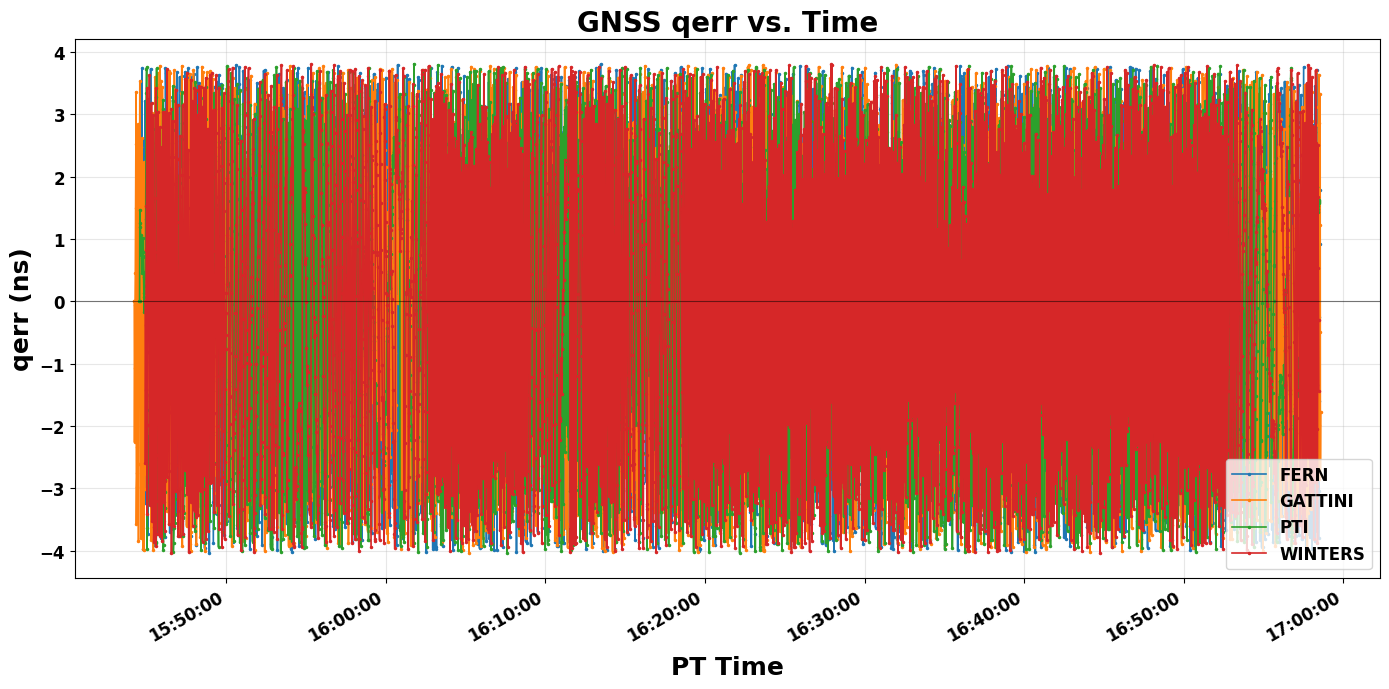

In [46]:
fig, ax = plt.subplots(figsize=(14, 7))

for node, node_df in df.groupby('node', sort=True):
    ax.plot(
        node_df['time_pt'],
        node_df['qerr_ns'],
        marker='.',
        markersize=3,
        linewidth=1.2,
        label=node,
    )

ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('GNSS qerr vs. Time', **title_font)
ax.set_xlabel('PT Time', labelpad=25, **label_font)
ax.set_ylabel('qerr (ns)', **label_font)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S', tz=PT_TZ))
ax.grid(True, which='major', alpha=0.3)
ax.legend(prop=legend_font, loc='best')
fig.autofmt_xdate(rotation=30)
plt.setp(ax.get_xticklabels() + ax.get_yticklabels(), fontweight='bold')
fig.tight_layout()
plt.show()

## qerr Histograms

Each node uses bins from the Freedman-Diaconis rule and is plotted with `alpha=0.7`.

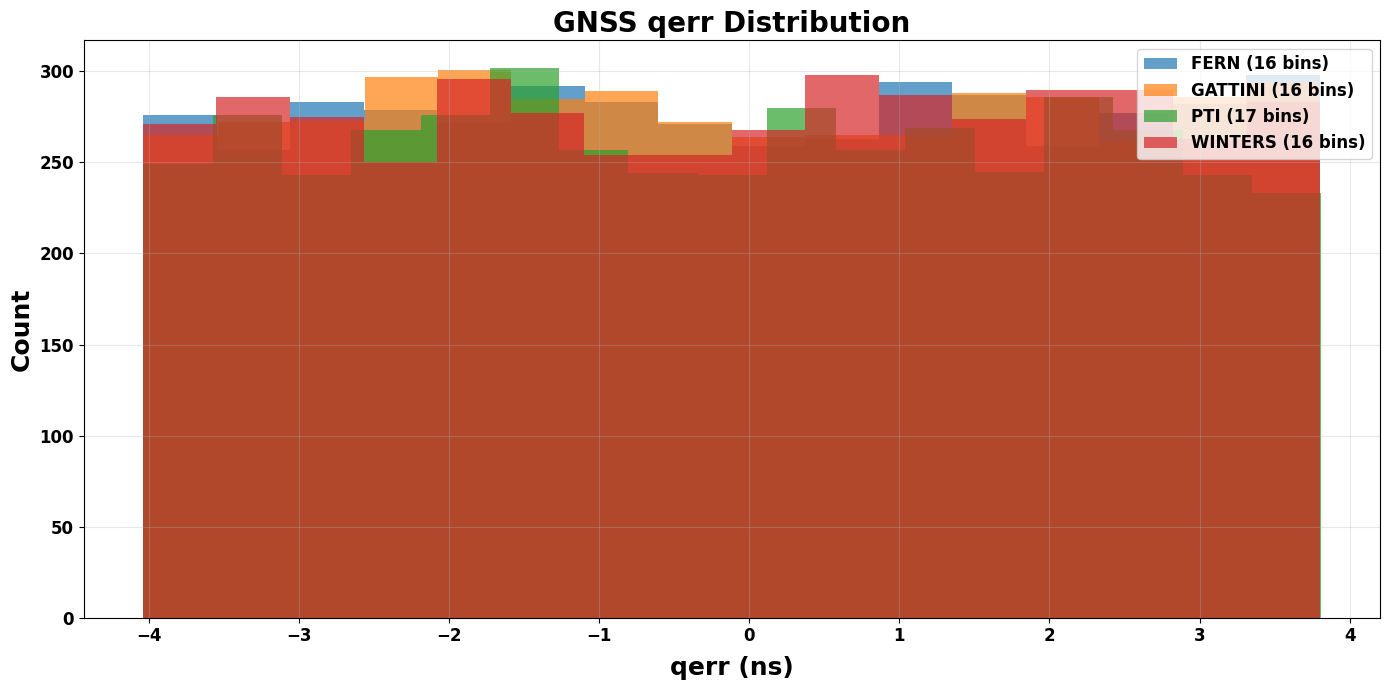

In [47]:
def freedman_diaconis_bins(values: pd.Series) -> int:
    """Return a robust Freedman-Diaconis bin count for one data set."""
    clean = values.dropna().astype(float)
    n = len(clean)
    if n < 2:
        return 1

    q25, q75 = clean.quantile([0.25, 0.75])
    iqr = q75 - q25
    data_range = clean.max() - clean.min()
    if iqr <= 0 or data_range <= 0:
        return min(10, max(1, n))

    bin_width = 2 * iqr / (n ** (1 / 3))
    if bin_width <= 0:
        return min(10, max(1, n))

    return max(1, int(round(data_range / bin_width)))


fig, ax = plt.subplots(figsize=(14, 7))
for node, node_df in df.groupby('node', sort=True):
    values = node_df['qerr_ns'].dropna()
    bins = freedman_diaconis_bins(values)
    ax.hist(values, bins=bins, alpha=0.7, label=f'{node} ({bins} bins)')

ax.set_title('GNSS qerr Distribution', **title_font)
ax.set_xlabel('qerr (ns)', labelpad=25, **label_font)
ax.set_ylabel('Count', **label_font)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, which='major', alpha=0.3)
ax.legend(prop=legend_font, loc='best')
plt.setp(ax.get_xticklabels() + ax.get_yticklabels(), fontweight='bold')
fig.tight_layout()
plt.show()

## Optional: Plot a Time Window

Set `start_time` and/or `stop_time` to ISO UTC strings to zoom into one data run.

In [ ]:
start_time = None  # Example: '2026-07-02T17:00:00Z'
stop_time = None   # Example: '2026-07-02T18:00:00Z'

window_df = df.copy()
if start_time:
    window_df = window_df[window_df['time_utc'] >= pd.Timestamp(start_time)]
if stop_time:
    window_df = window_df[window_df['time_utc'] <= pd.Timestamp(stop_time)]

fig, ax = plt.subplots(figsize=(14, 7))
for node, node_df in window_df.groupby('node', sort=True):
    ax.plot(node_df['time_pt'], node_df['qerr_ns'], marker='.', markersize=3, linewidth=1.2, label=node)

ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('GNSS qerr vs. Time', **title_font)
ax.set_xlabel('PT Time', labelpad=25, **label_font)
ax.set_ylabel('qerr (ns)', **label_font)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S', tz=PT_TZ))
ax.grid(True, which='major', alpha=0.3)
ax.legend(prop=legend_font, loc='best')
fig.autofmt_xdate(rotation=30)
plt.setp(ax.get_xticklabels() + ax.get_yticklabels(), fontweight='bold')
fig.tight_layout()
plt.show()